In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import scipy as scp

In [11]:
titanic = pd.read_csv("./titanic_mixed_data.csv")
titanic

,Cabin,Ticket,Number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [12]:
titanic["Number"].unique()

<StringArray>
['5', '3', '6', 'A']
Length: 4, dtype: str

Text(0.5, 1.0, 'Passengers Travling With')

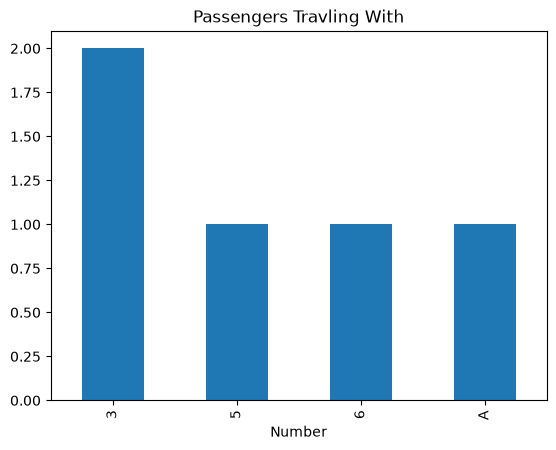

In [13]:
fig = titanic["Number"].value_counts().plot.bar()
fig.set_title("Passengers Travling With")

In [14]:
# extract numerical part
titanic['number_numerical'] = pd.to_numeric(titanic["Number"],errors='coerce',downcast='integer')

In [15]:
# extract categorical part
titanic['number_categorical'] = np.where(titanic['number_numerical'].isnull(),titanic['Number'],np.nan)

titanic

,Cabin,Ticket,Number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [16]:
titanic['Cabin'].unique()

<StringArray>
[nan, 'C85', 'C123']
Length: 3, dtype: str

In [17]:
titanic['Ticket'].unique()

<StringArray>
['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450']
Length: 5, dtype: str

In [18]:
titanic['cabin_num'] = titanic['Cabin'].str.extract('(\d+)') # captures numerical part
titanic['cabin_cat'] = titanic['Cabin'].str[0] # captures the first letter

titanic

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\aliab\AppData\Local\Temp\ipykernel_19152\2352805438.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  titanic['cabin_num'] = titanic['Cabin'].str.extract('(\d+)') # captures numerical part


,Cabin,Ticket,Number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

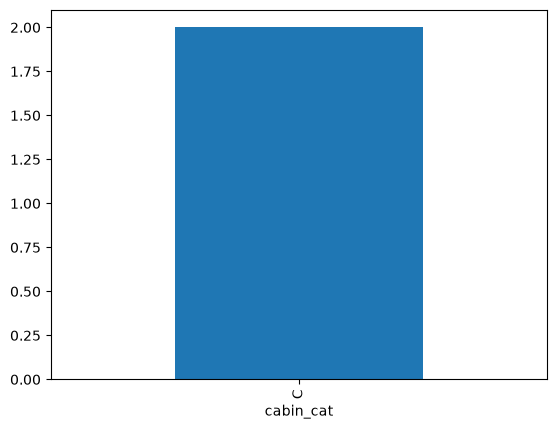

In [19]:
titanic['cabin_cat'].value_counts().plot(kind='bar')

In [20]:
# extract the last bit of ticket as number
titanic['ticket_num'] = titanic['Ticket'].apply(lambda s: s.split()[-1])
titanic['ticket_num'] = pd.to_numeric(titanic['ticket_num'], errors='coerce', downcast='integer')

# extract the first part of ticket as category
titanic['ticket_cat'] = titanic['Ticket'].apply(lambda s: s.split()[0])
titanic['ticket_cat'] = np.where(titanic['ticket_cat'].str.isdigit(), np.nan, titanic['ticket_cat'])

titanic

,Cabin,Ticket,Number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450,NaN


In [21]:
titanic['ticket_cat'].unique()

<StringArray>
['A/5', 'PC', 'STON/O2.', nan]
Length: 4, dtype: str